In [1]:
import pandas as pd

In [29]:
columns_headers = [
    "time", "gender", "highschool_%", "study_year","faculty","ung_grade_2023","accomodation","allowance","scholarship","study_hours",
    "party_week","drinks_night","missed_classes", "failed_classes", "in_relationship","parent_approve","relation_parent"
]
student_df = pd.read_csv("F:\github\Data preprocessing\Student_survay.csv", names=columns_headers, header=0)

<>:5: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:5: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
C:\Users\User\AppData\Local\Temp\ipykernel_16516\4292004400.py:5: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
  student_df = pd.read_csv("F:\github\Data preprocessing\Student_survay.csv", names=columns_headers, header=0)


In [3]:
student_df.drop("time",axis=1,inplace=True
                )

EDA

In [4]:
student_df.isna().sum()

gender              2
highschool_%        7
study_year         73
faculty             7
ung_grade_2023     86
accomodation       23
allowance          31
scholarship         8
study_hours         3
party_week          2
drinks_night        2
missed_classes      3
failed_classes      3
in_relationship     3
parent_approve      4
relation_parent     3
dtype: int64

In [5]:
student_df.describe

<bound method NDFrame.describe of      gender  highschool_% study_year                         faculty  \
0    Female          76.0   2nd Year          Arts & Social Sciences   
1      Male          89.0   2nd Year  Economic & Management Sciences   
2      Male          76.0   1st Year                    AgriSciences   
3      Male          89.0   2nd Year                     Engineering   
4    Female          74.0   2nd Year          Arts & Social Sciences   
..      ...           ...        ...                             ...   
401  Female          74.0        NaN                         Science   
402  Female          73.0   2nd Year  Economic & Management Sciences   
403  Female          86.0   1st Year                             NaN   
404    Male          85.0        NaN  Economic & Management Sciences   
405  Female          80.0   1st Year                             NaN   

     ung_grade_2023                                     accomodation  \
0              72.0  Private 

In [6]:
student_df.shape

(406, 16)

In [7]:
#Gender Distribution in the dataset
student_df.gender.value_counts(normalize=True)

gender
Male      0.534653
Female    0.465347
Name: proportion, dtype: float64

in the given study, 53.5% student are male and 46.5% are female

In [8]:
student_df.head()

,gender,highschool_%,study_year,faculty,ung_grade_2023,accomodation,allowance,scholarship,study_hours,party_week,drinks_night,missed_classes,failed_classes,in_relationship,parent_approve,relation_parent
0,Female,76.0,2nd Year,Arts & Social Sciences,72.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,8+,Only weekends,8+,3,0,Yes,Yes,Very close
1,Male,89.0,2nd Year,Economic & Management Sciences,75.0,Private accommodation/ stay with family/friends,R 7001 - R 8000,"Yes (NSFAS, etc...)",8+,Only weekends,3-5,4+,0,No,Yes,Very close
2,Male,76.0,1st Year,AgriSciences,55.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,3-5,2,8+,3,0,No,Yes,Very close
3,Male,89.0,2nd Year,Engineering,84.0,Private accommodation/ stay with family/friends,R 6001 - R 7000,No,3-5,3,8+,2,0,Yes,Yes,Very close
4,Female,74.0,2nd Year,Arts & Social Sciences,52.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,3-5,Only weekends,5-8,1,3,No,Yes,Fair


In [9]:
student_df.head(1)

,gender,highschool_%,study_year,faculty,ung_grade_2023,accomodation,allowance,scholarship,study_hours,party_week,drinks_night,missed_classes,failed_classes,in_relationship,parent_approve,relation_parent
0,Female,76.0,2nd Year,Arts & Social Sciences,72.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,8+,Only weekends,8+,3,0,Yes,Yes,Very close


In [14]:
#Relation betn Parent Approval and Parent Relationship
table=pd.crosstab(student_df.parent_approve,student_df.relation_parent)
table[["Close","Distant","Fair", "Very close"]]
table.T

parent_approve,No,Yes
relation_parent,,
Close,18,79
Distant,1,1
Fair,9,25
Very close,20,248


In [15]:
table.T

parent_approve,No,Yes
relation_parent,,
Close,18,79
Distant,1,1
Fair,9,25
Very close,20,248


<Axes: title={'center': 'Relation Between Parent Approval and Parent Relationship'}, xlabel='Degree of Parent Relationship', ylabel='Student Count'>

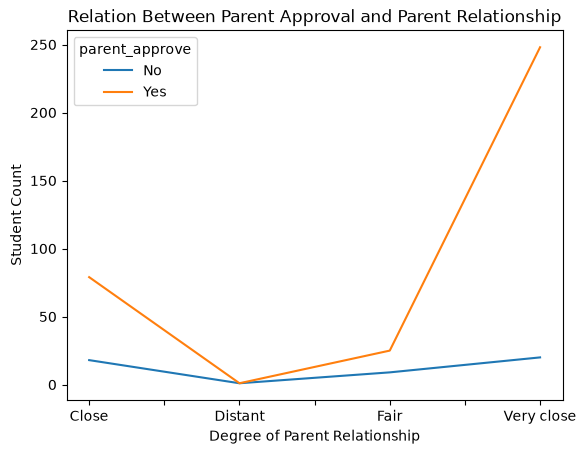

In [16]:
table.T.plot(kind="line"
             ,title="Relation Between Parent Approval and Parent Relationship",
             ylabel="Student Count",
             xlabel="Degree of Parent Relationship")

In [18]:
#Relation between Parent Relationship and Grade in Highschool
group_parent_relation=student_df.groupby(by="relation_parent")

In [24]:
group_parent_relation.head(2)

,gender,highschool_%,study_year,faculty,ung_grade_2023,accomodation,allowance,scholarship,study_hours,party_week,drinks_night,missed_classes,failed_classes,in_relationship,parent_approve,relation_parent
0,Female,76.0,2nd Year,Arts & Social Sciences,72.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,8+,Only weekends,8+,3,0,Yes,Yes,Very close
1,Male,89.0,2nd Year,Economic & Management Sciences,75.0,Private accommodation/ stay with family/friends,R 7001 - R 8000,"Yes (NSFAS, etc...)",8+,Only weekends,3-5,4+,0,No,Yes,Very close
4,Female,74.0,2nd Year,Arts & Social Sciences,52.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,3-5,Only weekends,5-8,1,3,No,Yes,Fair
9,Male,83.0,NaN,Science,NaN,NaN,R 6001 - R 7000,No,3-5,3,5-8,4+,0,No,Yes,Close
10,Female,75.0,NaN,AgriSciences,NaN,NaN,R 4001- R 5000,No,5-8,2,5-8,0,0,No,Yes,Close
16,Female,86.0,NaN,Engineering,NaN,Private accommodation/ stay with family/friends,NaN,No,3-5,1,3-5,0,0,No,Yes,Fair
54,Male,98.0,1st Year,Engineering,89.0,Private accommodation/ stay with family/friends,R 4001- R 5000,"Yes (NSFAS, etc...)",1-3,Only weekends,8+,0,4+,Yes,No,Distant
116,Male,85.0,1st Year,Science,88.0,Private accommodation/ stay with family/friends,R 4001- R 5000,"Yes (NSFAS, etc...)",8+,Only weekends,0,0,0,Yes,Yes,Distant


In [26]:
relation=group_parent_relation['ung_grade_2023'].aggregate(['min','max','mean'])

In [27]:
relation=relation.T[["Distant","Fair","Close","Very close"]]

In [31]:
relation

relation_parent,Distant,Fair,Close,Very close
min,88.0,50.000000,50.000000,30.000000
max,89.0,85.000000,95.220000,92.000000
mean,88.5,66.258065,65.220769,66.527356


<Axes: xlabel='relation_parent'>

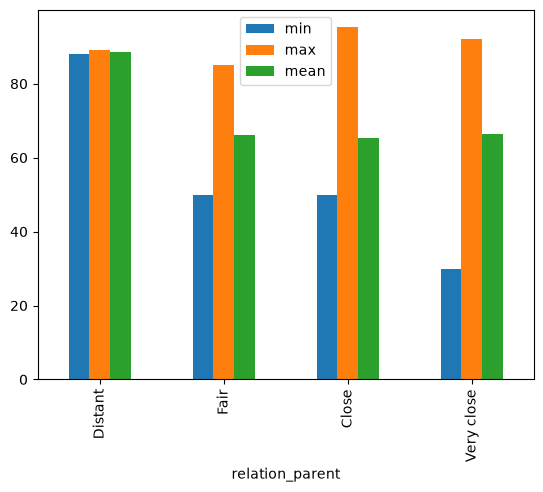

In [28]:
relation.T.plot(kind="bar")